# Train and Visualize a Field Segmentation Experiment

This notebook is the main workflow for Colab or local training. It loads an experiment config, prepares FTW data when available, trains the model, evaluates metrics, and shows predictions.

In [1]:
from pathlib import Path
import os
import sys

# Colab and Drive paths.
PROJECT_ROOT = Path('/content/drive/My Drive/HLCV_final_project')
FTW_ZIP = Path('/content/drive/MyDrive/ftw_austria_croatia_denmark.zip')
FTW_COUNTRIES = ['austria', 'croatia', 'denmark']

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount('/content/drive')
else:
    PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

if not PROJECT_ROOT.exists():
    raise FileNotFoundError(f'Project folder not found: {PROJECT_ROOT}')
if not (PROJECT_ROOT / 'requirements.txt').exists():
    raise FileNotFoundError(f'requirements.txt not found under: {PROJECT_ROOT}')

os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Using project root: {PROJECT_ROOT}')
print(f'Using FTW zip: {FTW_ZIP}')
print(f'Using FTW countries: {FTW_COUNTRIES}')
print(f'Current working directory: {Path.cwd()}')

Mounted at /content/drive
Using project root: /content/drive/My Drive/HLCV_final_project
Using FTW zip: /content/drive/MyDrive/ftw_austria_croatia_denmark.zip
Using FTW countries: ['austria', 'croatia', 'denmark']
Current working directory: /content/drive/My Drive/HLCV_final_project


In [2]:
# Install dependencies once per fresh Colab runtime.
# Colab already provides its own notebook/Jupyter stack. Installing `jupyter`
# from requirements.txt can upgrade jupyter-server and conflict with google-colab.
import subprocess
import sys
from pathlib import Path

colab_requirements = Path('/tmp/hlcv_colab_requirements.txt')
skip_packages = ('jupyter', 'notebook', 'jupyter-server', 'google-colab')

filtered_requirements = []
for raw_line in Path('requirements.txt').read_text().splitlines():
    line = raw_line.strip()
    package_name = line.split('==')[0].split('>=')[0].split('<=')[0].split('~=')[0].split('>')[0].split('<')[0].strip().lower()
    if line and not line.startswith('#') and package_name in skip_packages:
        print(f'Skipping Colab-managed package: {line}')
        continue
    filtered_requirements.append(raw_line)

colab_requirements.write_text('\n'.join(filtered_requirements) + '\n')
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', '-r', str(colab_requirements)])

Skipping Colab-managed package: jupyter>=1.0


0

In [3]:
# Optional for FTW training: unzip the Austria/Croatia/Denmark Drive archive into fast Colab local storage.
# Supported archive layouts include ftw/<country>/... and <country>/...
from pathlib import Path
import subprocess

LOCAL_CONTENT_ROOT = Path('/content')
LOCAL_FTW_ROOT = LOCAL_CONTENT_ROOT / 'ftw'


def is_ftw_country_dir(path):
    path = Path(path)
    return (
        path.is_dir()
        and (path / 's2_images').is_dir()
        and (path / 'label_masks').is_dir()
    )


def has_usable_ftw_chips(path):
    path = Path(path)
    required_dirs = [
        path / 's2_images' / 'window_a',
        path / 's2_images' / 'window_b',
        path / 'label_masks' / 'instance',
        path / 'label_masks' / 'semantic_2class',
    ]
    return all(d.is_dir() and any(d.glob('*.tif')) for d in required_dirs)


def known_ftw_root_candidates():
    # Handles ZIPs that contain an ftw/ wrapper as well as country folders directly.
    return [
        LOCAL_FTW_ROOT,
        LOCAL_FTW_ROOT / 'ftw',
        LOCAL_FTW_ROOT / 'data' / 'ftw',
        LOCAL_CONTENT_ROOT / 'data' / 'ftw',
    ]


def find_ftw_data_root():
    for root in known_ftw_root_candidates():
        if all(has_usable_ftw_chips(root / country) for country in FTW_COUNTRIES):
            return root
    return None


def list_ftw_countries(ftw_root):
    ftw_root = Path(ftw_root)
    return sorted(child.name for child in ftw_root.iterdir() if is_ftw_country_dir(child))


def count_ftw_chips(ftw_root, country):
    country_dir = Path(ftw_root) / country
    return {
        label: sum(1 for _ in (country_dir / relative_path).glob('*.tif'))
        for label, relative_path in {
            'window_a': 's2_images/window_a',
            'window_b': 's2_images/window_b',
            'instance': 'label_masks/instance',
            'semantic_2class': 'label_masks/semantic_2class',
        }.items()
    }


def print_ftw_candidate_status():
    print('Checked FTW root candidates:')
    for root in known_ftw_root_candidates():
        present = [country for country in FTW_COUNTRIES if has_usable_ftw_chips(root / country)]
        print(f'  {root}: usable requested countries={present}')


if IN_COLAB:
    ftw_data_root = find_ftw_data_root()
    if ftw_data_root is not None:
        print(f'FTW data already available: {ftw_data_root}')
    elif not FTW_ZIP.exists():
        raise FileNotFoundError(
            f'No FTW data found and ZIP does not exist: {FTW_ZIP}. '
            'Update FTW_ZIP to point to the new archive in Google Drive.'
        )
    else:
        print(f'Unzipping {FTW_ZIP} to {LOCAL_FTW_ROOT} ...')
        LOCAL_FTW_ROOT.mkdir(parents=True, exist_ok=True)
        subprocess.run(['unzip', '-q', '-o', str(FTW_ZIP), '-d', str(LOCAL_FTW_ROOT)], check=True)
        ftw_data_root = find_ftw_data_root()

    if ftw_data_root is None:
        print_ftw_candidate_status()
        raise FileNotFoundError(
            'Could not find all requested countries after extraction. Expected '
            f'an FTW root containing: {FTW_COUNTRIES}'
        )

    print(f'FTW data root for config: {ftw_data_root}')
    print(f'Available countries: {list_ftw_countries(ftw_data_root)}')
    for country in FTW_COUNTRIES:
        print(f'{country}: {count_ftw_chips(ftw_data_root, country)}')
else:
    print('Not running in Colab; local data paths are unchanged.')

Unzipping /content/drive/MyDrive/ftw_austria_croatia_denmark.zip to /content/ftw ...
FTW data root for config: /content/ftw/ftw
Available countries: ['austria', 'croatia', 'denmark']
austria: {'window_a': 6685, 'window_b': 6686, 'instance': 6685, 'semantic_2class': 6685}
croatia: {'window_a': 3482, 'window_b': 3482, 'instance': 3482, 'semantic_2class': 3482}
denmark: {'window_a': 3560, 'window_b': 3560, 'instance': 3560, 'semantic_2class': 3560}


In [4]:
# Colab GPU selection: Runtime > Change runtime type > GPU.
!nvidia-smi

import torch
print('CUDA available:', torch.cuda.is_available())
print('GPU:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'No GPU')

Sat Jul 18 16:31:24 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   42C    P8             12W /   72W |       0MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
from copy import deepcopy
import importlib
import matplotlib.pyplot as plt

from cfgs import field_segmentation
field_segmentation = importlib.reload(field_segmentation)
from src.utils.utils import seed_everything
from src.utils.visualization import show_batch, show_predictions

CONFIG_NAMES = [
    # 'ftw_three_head_boundary_bce_w20_s012_headw2_other3',
    'ftw_three_head_boundary_bce_w20_s012_headw2_other3_nosdf',
]
CONFIG_NAME = CONFIG_NAMES[0]  # used for the preview cells before the sweep
NOTEBOOK_NUM_WORKERS = 4  # Recommended Colab range: 4-6 workers.
MAX_NOTEBOOK_EPOCHS = 60  # set an int for quick tests; None uses each config default


def build_config(config_name):
    seed_everything(0)
    cfg = deepcopy(getattr(field_segmentation, config_name))

    if 'data_dir' in cfg['data_args']:
        local_ftw_root = find_ftw_data_root() if 'find_ftw_data_root' in globals() else None
        if local_ftw_root is not None:
            cfg['data_args']['data_dir'] = str(local_ftw_root)
            cfg['data_args']['countries'] = list(FTW_COUNTRIES)
            print(f"[{config_name}] Using local FTW data root: {cfg['data_args']['data_dir']}")
            print(f"[{config_name}] Training countries: {cfg['data_args']['countries']}")
        else:
            print(f"[{config_name}] Using configured FTW data root: {cfg['data_args']['data_dir']}")

    # None means no artificial sample cap; official parquet splits still separate train/val/test.
    cfg['data_args']['max_samples'] = None
    cfg['data_args']['max_train_samples'] = None
    cfg['data_args']['max_val_samples'] = None
    cfg['data_args']['max_test_samples'] = None
    cfg['data_args']['num_workers'] = NOTEBOOK_NUM_WORKERS
    if 'sdf_cache_dir' in cfg['data_args']:
        cfg['data_args']['sdf_cache_dir'] = '/content/sdf_cache'
    cfg['data_args']['pin_memory'] = True
    if NOTEBOOK_NUM_WORKERS > 0:
        cfg['data_args']['prefetch_factor'] = 2
    else:
        cfg['data_args'].pop('prefetch_factor', None)
        cfg['data_args'].pop('persistent_workers', None)
    if MAX_NOTEBOOK_EPOCHS is not None:
        cfg['trainer_config']['epochs'] = MAX_NOTEBOOK_EPOCHS
    return cfg


def build_loaders(cfg):
    data_module = cfg['datamodule'](**cfg['data_args'])
    return data_module, data_module.get_loader(), data_module.get_heldout_loader()


config = build_config(CONFIG_NAME)
config['name'], config['model_arch'].__name__, config['data_args'], config['criterion_args']

[ftw_three_head_boundary_bce_w20_s012_headw2_other3_nosdf] Using local FTW data root: /content/ftw/ftw
[ftw_three_head_boundary_bce_w20_s012_headw2_other3_nosdf] Training countries: ['austria', 'croatia', 'denmark']


('ftw_three_head_boundary_bce_w20_s012_headw2_other3_nosdf',
 'ThreeHeadUNet',
 {'data_dir': '/content/ftw/ftw',
  'image_size': 256,
  'batch_size': 16,
  'shuffle': True,
  'max_train_samples': None,
  'heldout_split': 0.0,
  'num_workers': 4,
  'sdf_cache_dir': '/content/sdf_cache',
  'transform_preset': 'FTW_WithAugmentation',
  'countries': ['austria', 'croatia', 'denmark'],
  'max_samples': None,
  'max_val_samples': None,
  'max_test_samples': None,
  'pin_memory': True,
  'prefetch_factor': 2},
 {'bce_weight': 1.0,
  'dice_weight': 1.0,
  'distance_weight': 0.0,
  'tv_weight': 0.0,
  'boundary_weight': 20.0,
  'boundary_sigma': 0.12,
  'boundary_head_weight': 2.0,
  'boundary_target_threshold': 0.12})

In [6]:
# Hide harmless PyTorch DataLoader cleanup noise in Colab when num_workers > 0.
import sys

if not hasattr(sys, '_hlcv_default_unraisablehook'):
    sys._hlcv_default_unraisablehook = sys.unraisablehook

def _hide_colab_dataloader_cleanup_error(unraisable):
    exc = unraisable.exc_value
    obj = repr(unraisable.object)
    if (
        isinstance(exc, AssertionError)
        and 'can only test a child process' in str(exc)
        and '_MultiProcessingDataLoaderIter' in obj
    ):
        return
    sys._hlcv_default_unraisablehook(unraisable)

sys.unraisablehook = _hide_colab_dataloader_cleanup_error


## Load Data

The data module returns images, binary masks, instance IDs, and signed-distance-field targets. In Colab, the setup cells unpack the archive into local storage, discover the FTW root, and load every available official training chip from Austria, Croatia, and Denmark. Official validation/test split metadata remains separate.

Preview config: ftw_three_head_boundary_bce_w20_s012_headw2_other3_nosdf
Boundary weight: 20.0
Epochs: 60
Eval period: 2
Batch image shape: (16, 8, 256, 256)
Batch mask shape: (16, 1, 256, 256)
Batch distance shape: (16, 1, 256, 256)
Train images: 10949
Validation images: 1348
Train batches: 685
Validation batches: 85


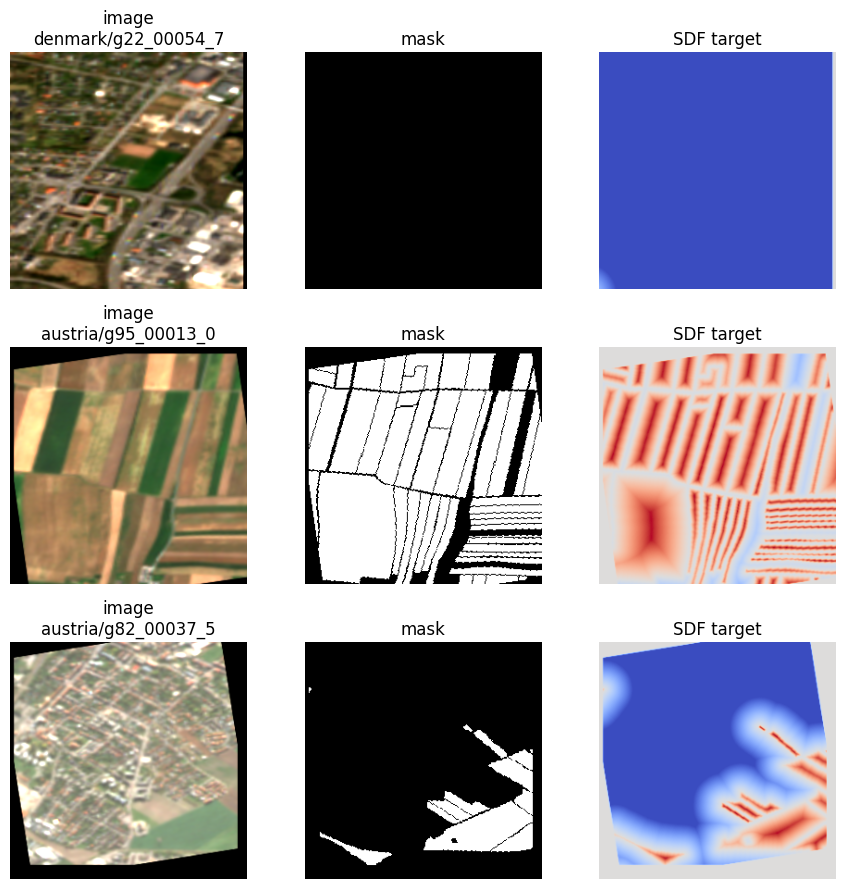

In [7]:
# Preview the first config's data before running the full sweep.
dm, train_loader, valid_loader = build_loaders(config)

batch = next(iter(train_loader))
print('Preview config:', config['name'])
print('Boundary weight:', config['criterion_args'].get('boundary_weight'))
print('Epochs:', config['trainer_config']['epochs'])
print('Eval period:', config['trainer_config']['eval_period'])
print('Batch image shape:', tuple(batch['image'].shape))
print('Batch mask shape:', tuple(batch['mask'].shape))
print('Batch distance shape:', tuple(batch['distance'].shape))
print('Train images:', len(train_loader.dataset))
print('Validation images:', len(valid_loader.dataset))
print('Train batches:', len(train_loader))
print('Validation batches:', len(valid_loader))
show_batch(batch, max_items=3);

## Train Other-Three-Country Comparison

This cell trains the three-head `headw2` model on Austria, Croatia, and Denmark, comparing the normal SDF-head version against the no-SDF-head ablation. `MAX_NOTEBOOK_EPOCHS` is set to 60 in the setup cell.

In [8]:
import gc
import time
from pathlib import Path

import pandas as pd
import torch


def best_eval_row(history, metric='eval_boundary_iou'):
    candidates = [row for row in history if metric in row]
    if not candidates:
        return None
    return max(candidates, key=lambda row: row[metric])


sweep_results = []
histories = {}

for run_index, config_name in enumerate(CONFIG_NAMES, start=1):
    print(f'\n=== [{run_index}/{len(CONFIG_NAMES)}] Training {config_name} ===')
    config = build_config(config_name)
    dm, train_loader, valid_loader = build_loaders(config)

    trainer = config['trainer_module'](
        config=config,
        log_dir=PROJECT_ROOT / 'Logs',
        train_loader=train_loader,
        eval_loader=valid_loader,
    )

    start_time = time.time()
    history = trainer.train()
    train_minutes = (time.time() - start_time) / 60
    final_eval_result = trainer.evaluate(valid_loader)
    best_row = best_eval_row(history)
    histories[config_name] = history

    result_row = {
        'config': config_name,
        'boundary_weight': config['criterion_args'].get('boundary_weight'),
        'epochs': config['trainer_config']['epochs'],
        'eval_period': config['trainer_config']['eval_period'],
        'train_minutes': train_minutes,
        'best_epoch_by_boundary_iou': best_row.get('epoch') if best_row else None,
        'best_model_path': str(Path(config['trainer_config']['save_dir']) / config['name'] / 'best_eval_boundary_iou_model.pth'),
    }
    if best_row is not None:
        result_row.update({
            key.removeprefix('eval_'): float(value)
            for key, value in best_row.items()
            if key.startswith('eval_') and isinstance(value, (int, float))
        })
    result_row.update({
        f'final_{key}': float(value)
        for key, value in final_eval_result.items()
        if isinstance(value, (int, float))
    })
    sweep_results.append(result_row)

    print(f"Finished {config_name} in {train_minutes:.2f} min")
    print({
        'best_epoch_by_boundary_iou': result_row.get('best_epoch_by_boundary_iou'),
        'pixel_iou': result_row.get('pixel_iou'),
        'miou': result_row.get('miou'),
        'boundary_iou': result_row.get('boundary_iou'),
        'loss': result_row.get('loss'),
        'best_model_path': result_row.get('best_model_path'),
    })

    if run_index < len(CONFIG_NAMES):
        del trainer, dm, train_loader, valid_loader, history, final_eval_result
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

sweep_results_df = pd.DataFrame(sweep_results)
sweep_results_df



=== [1/1] Training ftw_three_head_boundary_bce_w20_s012_headw2_other3_nosdf ===
[ftw_three_head_boundary_bce_w20_s012_headw2_other3_nosdf] Using local FTW data root: /content/ftw/ftw
[ftw_three_head_boundary_bce_w20_s012_headw2_other3_nosdf] Training countries: ['austria', 'croatia', 'denmark']


INFO:ftw_three_head_boundary_bce_w20_s012_headw2_other3_nosdf:ThreeHeadUNet(
  (inc): DoubleConv(
    (block): Sequential(
      (0): Conv2d(8, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (down1): Down(
    (block): Sequential(
      (0): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (1): DoubleConv(
        (block): Sequential(
          (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
          (3): Conv2d(64, 64, kernel_size=(3, 

Epoch 1:   0%|          | 0/685 [00:00<?, ?it/s]

INFO:ftw_three_head_boundary_bce_w20_s012_headw2_other3_nosdf:epoch: 1 | loss: 2.0182 | bce: 0.3954 | raw_bce: 0.4501 | dice_loss: 0.5213 | distance_loss: 0.0000 | weighted_distance_loss: 0.0000 | distance_loss_fraction: 0.0000 | boundary_head_loss: 0.5507 | weighted_boundary_head_loss: 1.1015 | boundary_head_loss_fraction: 0.5442 | boundary_target_fraction: 0.2914 | boundary_pos_weight: 2.4868 | tv_loss: 2262.6596 | boundary_weight_mean: 6.4153


epoch: 1 | loss: 2.0182 | bce: 0.3954 | raw_bce: 0.4501 | dice_loss: 0.5213 | distance_loss: 0.0000 | weighted_distance_loss: 0.0000 | distance_loss_fraction: 0.0000 | boundary_head_loss: 0.5507 | weighted_boundary_head_loss: 1.1015 | boundary_head_loss_fraction: 0.5442 | boundary_target_fraction: 0.2914 | boundary_pos_weight: 2.4868 | tv_loss: 2262.6596 | boundary_weight_mean: 6.4153


...

INFO:ftw_three_head_boundary_bce_w20_s012_headw2_other3_nosdf:epoch: 60 | loss: 1.2757 | bce: 0.2778 | raw_bce: 0.2172 | dice_loss: 0.3351 | distance_loss: 0.0000 | weighted_distance_loss: 0.0000 | distance_loss_fraction: 0.0000 | boundary_head_loss: 0.3314 | weighted_boundary_head_loss: 0.6628 | boundary_head_loss_fraction: 0.5199 | boundary_target_fraction: 0.2913 | boundary_pos_weight: 2.4877 | tv_loss: 2343.0274 | boundary_weight_mean: 6.4126 | eval_loss: 1.7697 | eval_bce: 0.3969 | eval_raw_bce: 0.2364 | eval_dice_loss: 0.3062 | eval_distance_loss: 0.0000 | eval_weighted_distance_loss: 0.0000 | eval_distance_loss_fraction: 0.0000 | eval_boundary_head_loss: 0.5333 | eval_weighted_boundary_head_loss: 1.0667 | eval_boundary_head_loss_fraction: 0.6043 | eval_boundary_target_fraction: 0.2017 | eval_boundary_pos_weight: 6.1761 | eval_tv_loss: 2461.0092 | eval_boundary_weight_mean: 4.6877 | eval_pixel_iou: 0.7291 | eval_miou: 0.6812 | eval_boundary_iou: 0.3618


epoch: 60 | loss: 1.2757 | bce: 0.2778 | raw_bce: 0.2172 | dice_loss: 0.3351 | distance_loss: 0.0000 | weighted_distance_loss: 0.0000 | distance_loss_fraction: 0.0000 | boundary_head_loss: 0.3314 | weighted_boundary_head_loss: 0.6628 | boundary_head_loss_fraction: 0.5199 | boundary_target_fraction: 0.2913 | boundary_pos_weight: 2.4877 | tv_loss: 2343.0274 | boundary_weight_mean: 6.4126 | eval_loss: 1.7697 | eval_bce: 0.3969 | eval_raw_bce: 0.2364 | eval_dice_loss: 0.3062 | eval_distance_loss: 0.0000 | eval_weighted_distance_loss: 0.0000 | eval_distance_loss_fraction: 0.0000 | eval_boundary_head_loss: 0.5333 | eval_weighted_boundary_head_loss: 1.0667 | eval_boundary_head_loss_fraction: 0.6043 | eval_boundary_target_fraction: 0.2017 | eval_boundary_pos_weight: 6.1761 | eval_tv_loss: 2461.0092 | eval_boundary_weight_mean: 4.6877 | eval_pixel_iou: 0.7291 | eval_miou: 0.6812 | eval_boundary_iou: 0.3618


Eval:   0%|          | 0/85 [00:00<?, ?it/s]

Finished ftw_three_head_boundary_bce_w20_s012_headw2_other3_nosdf in 150.47 min
{'best_epoch_by_boundary_iou': 58, 'pixel_iou': 0.7352652672459098, 'miou': 0.6792732922469868, 'boundary_iou': 0.36794705548707174, 'loss': 1.7518033616683062, 'best_model_path': '/content/drive/My Drive/HLCV_final_project/Saved/ftw_three_head_boundary_bce_w20_s012_headw2_other3_nosdf/best_eval_boundary_iou_model.pth'}


,config,boundary_weight,epochs,eval_period,train_minutes,best_epoch_by_boundary_iou,best_model_path,loss,bce,raw_bce,...,final_boundary_head_loss,final_weighted_boundary_head_loss,final_boundary_head_loss_fraction,final_boundary_target_fraction,final_boundary_pos_weight,final_tv_loss,final_boundary_weight_mean,final_pixel_iou,final_miou,final_boundary_iou
0,ftw_three_head_boundary_bce_w20_s012_headw2_ot...,20.0,60,2,150.467579,58,/content/drive/My Drive/HLCV_final_project/Sav...,1.751803,0.394862,0.225089,...,0.533326,1.066653,0.604251,0.201674,6.176072,2461.009208,4.687736,0.729129,0.681237,0.36178


In [9]:
metric_columns = [
    'config',
    'boundary_weight',
    'eval_period',
    'best_epoch_by_boundary_iou',
    'pixel_iou',
    'miou',
    'boundary_iou',
    'loss',
    'bce',
    'raw_bce',
    'dice_loss',
    'distance_loss',
    'best_model_path',
]
available_metric_columns = [column for column in metric_columns if column in sweep_results_df.columns]
summary_df = sweep_results_df[available_metric_columns].sort_values('boundary_iou', ascending=False)
summary_df


,config,boundary_weight,eval_period,best_epoch_by_boundary_iou,pixel_iou,miou,boundary_iou,loss,bce,raw_bce,dice_loss,distance_loss,best_model_path
0,ftw_three_head_boundary_bce_w20_s012_headw2_ot...,20.0,2,58,0.735265,0.679273,0.367947,1.751803,0.394862,0.225089,0.308263,0.0,/content/drive/My Drive/HLCV_final_project/Sav...


## Visualize Predictions

This visualizes the last trained configuration from the sweep. The final entry in `CONFIG_NAMES` remains in memory for visualization.

Visualizing config: ftw_three_head_boundary_bce_w20_s012_headw2_other3_nosdf


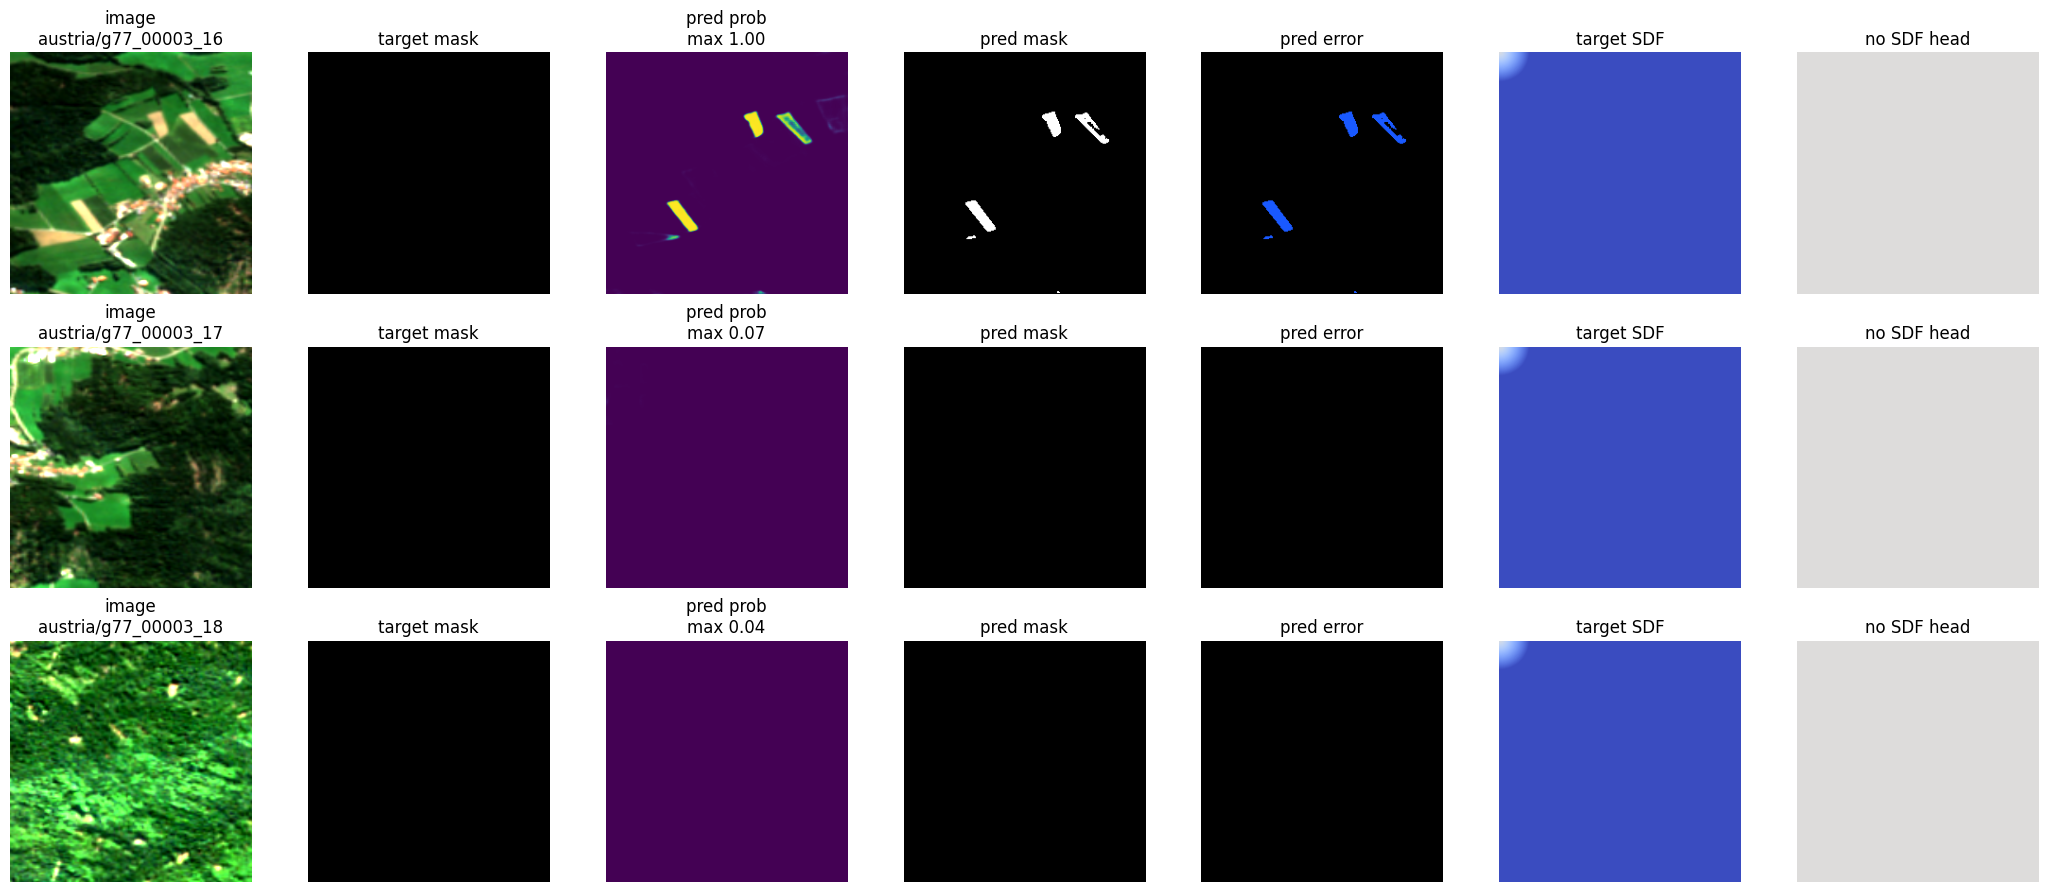

In [10]:
batch = next(iter(valid_loader))
print('Visualizing config:', config['name'])
show_predictions(trainer.model, batch, device=trainer.device, max_items=3);

## configs comparison

In [11]:
import subprocess
import sys
from pathlib import Path


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    candidates = [start, *start.parents]

    # Common Colab Drive locations if this block is run without previous setup cells.
    for drive_root in [Path('/content/drive/My Drive'), Path('/content/drive/MyDrive')]:
        if drive_root.exists():
            candidates.extend(drive_root.glob('HLCV_final_project'))

    for candidate in candidates:
        script = candidate / 'scripts' / 'evaluation' / 'compare_boundary_weights.py'
        if script.exists():
            return candidate
    raise FileNotFoundError(
        'Could not find scripts/evaluation/compare_boundary_weights.py. '
        'Run this block from inside HLCV_final_project or mount Google Drive first.'
    )


project_root = find_project_root()
compare_script = project_root / 'scripts' / 'evaluation' / 'compare_boundary_weights.py'
log_dir = project_root / 'Logs'

print(f'Project root: {project_root}')
print(f'Log dir: {log_dir}')

result = subprocess.run(
    [sys.executable, str(compare_script), '--log-dir', str(log_dir)],
    cwd=project_root,
    text=True,
    capture_output=True,
)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)
    raise RuntimeError(f'compare_boundary_weights.py failed with exit code {result.returncode}')

Project root: /content/drive/My Drive/HLCV_final_project
Log dir: /content/drive/My Drive/HLCV_final_project/Logs
config                                                   | boundary_weight | distance_weight | distance_boundary_weight | boundary_head_weight | best_epoch_by_boundary_iou | pixel_iou | miou   | boundary_iou | loss   | bce    | raw_bce | dice_loss | distance_loss | raw_distance_loss | weighted_distance_loss | distance_loss_fraction | boundary_head_loss | weighted_boundary_head_loss | boundary_head_loss_fraction | boundary_target_fraction | status     
-------------------------------------------------------- | --------------- | --------------- | ------------------------ | -------------------- | -------------------------- | --------- | ------ | ------------ | ------ | ------ | ------- | --------- | ------------- | ----------------- | ---------------------- | ---------------------- | ------------------ | --------------------------- | --------------------------- | -------------

## Checkpoints

The final model weights are saved under `Saved/<experiment_name>/last_model.pth`.

## Evaluate Saved Checkpoints

Run this after both the baseline and dual-head checkpoints exist. It evaluates the same validation split at multiple probability thresholds.

## Save and Display Visualizations

This block saves a prediction panel from the in-memory model trained above and a label-layout diagnostic panel. It still works when checkpoint saving is disabled.

